In [3]:
import pandas as pd
import csv

df = pd.read_csv(
    "zomato.csv",
    engine="python",
    quoting=csv.QUOTE_MINIMAL,
    on_bad_lines="skip",
    encoding="utf-8"
)

print(df.shape)
df.head()

(56252, 13)


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [4]:
df.iloc[10]

,10
address,"2470, 21 Main Road, 25th Cross, Banashankari, ..."
name,Smacznego
online_order,Yes
book_table,No
rate,4.2/5
votes,504
phone,+91 9945230807\r\n+91 9743804471
location,Banashankari
rest_type,Cafe
dish_liked,"Waffles, Pasta, Coleslaw Sandwich, Choco Waffl..."


In [5]:
df.shape

(56252, 13)

In [6]:
df['rate'].sample(20)

,rate
23588,!')
30453,3.7 /5
42149,3.2 /5
22405,3.2/5
16911,3.7/5
3710,NEW
56212,difficult to acquire a table.\nThe brewed bee...
21925,3.8/5
42140,NaN
9395,3.6/5


In [7]:
df[df['rate'].str.len() > 10][['name', 'rate']].head(10)

,name,rate
9,service was sluggish as they took too long to...,\nTop floor
33,'RATED\n not that much worth'),('Rated 1.0'
37,Will Recommend To Everyone.\n\nCheers!!'),('Rated 5.0'
42,'RATED\n We enjoyed our dinner,always a good experience
49,and the crust was made amazing also so was th...,a mocktail and did i just hear unlimited dess...
63,('Rated 4.0','RATED\n First thing about this place is.. P...
67,this was amazing,('Rated 4.0'
81,'RATED\n Best Delivery Restaurants that serv...,chicken chengezi and assorted breads. I was a...
215,"""""RATED\n The buffet is inr 330 pp all incl....",you can definitely hang in domino's and get a...
258,"""""RATED\n The food here is just about an ave...",('Rated 2.5'


In [8]:
import re

# Keep rows where rate is:
# 4.1/5, 4.1 /5, NEW, -, or missing

pattern = r'^\d\.\d\s?/5$'

df = df[
    df['rate'].isna() |
    df['rate'].isin(['NEW', '-']) |
    df['rate'].str.match(pattern, na=False)
]

In [9]:
df.shape

(51780, 13)

In [10]:
df[df['rate'].str.len() > 10][['name','rate']]

,name,rate


In [11]:
## Data Cleaning

##- Removed duplicate records.
##- Handled missing values.
##- Removed corrupted rating rows.

In [12]:
# Remove '/5' and extra spaces
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = df['rate'].str.strip()

# Replace NEW and - with missing values
df['rate'] = df['rate'].replace(['NEW', '-'], None)

# Convert to numeric
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [13]:
df['rate'].head(10)

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8
5,3.8
6,3.6
7,4.6
8,4.0
10,4.2


In [14]:
df['rate'].dtype

dtype('float64')

In [15]:
# Rename the column (easier to work with)
df.rename(columns={'approx_cost(for two people)': 'approx_cost'}, inplace=True)

# Remove commas
df['approx_cost'] = df['approx_cost'].str.replace(',', '', regex=False)

# Convert to numeric
df['approx_cost'] = pd.to_numeric(df['approx_cost'], errors='coerce')

In [16]:
df['approx_cost'].head(10)

,approx_cost
0,800.0
1,800.0
2,800.0
3,300.0
4,600.0
5,600.0
6,800.0
7,600.0
8,700.0
10,550.0


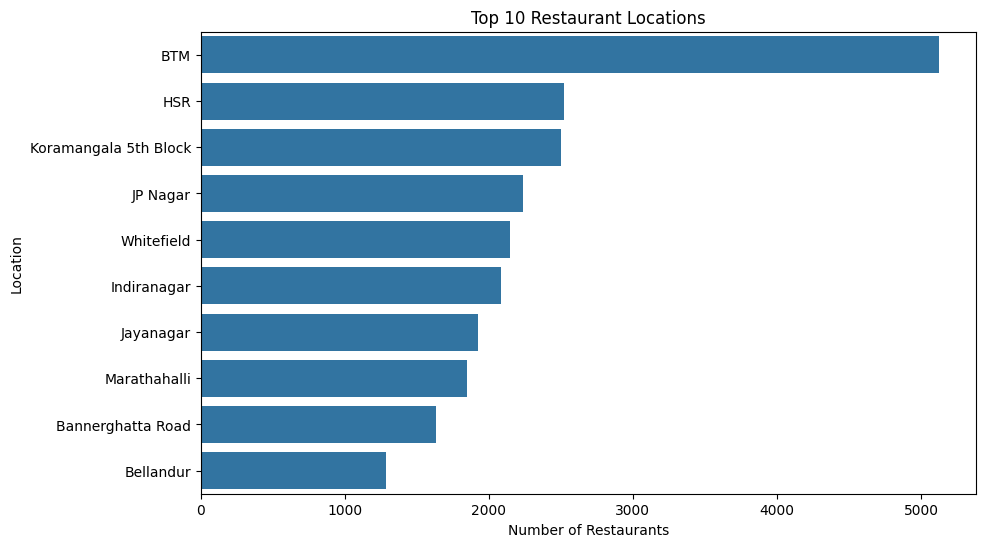

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 restaurant locations
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_locations.values, y=top_locations.index)

plt.title("Top 10 Restaurant Locations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")

plt.show()

Observation:
BTM has the highest number of restaurants, making it the most popular food hub in the dataset. HSR and Koramangala 5th Block also have a large concentration of restaurants. These locations indicate areas with high customer demand and strong competition among restaurants.

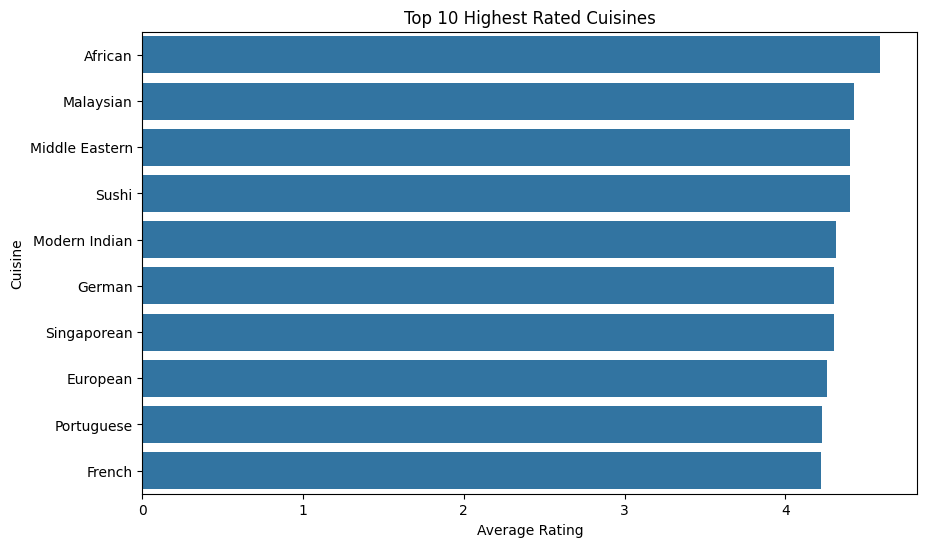

In [18]:
# Split cuisines and keep the first cuisine
df['main_cuisine'] = df['cuisines'].str.split(',').str[0].str.strip()

# Average rating by cuisine
top_cuisines = (
    df.groupby('main_cuisine')['rate']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)

plt.title("Top 10 Highest Rated Cuisines")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")

plt.show()

Observation:
African cuisine has the highest average rating in the dataset, followed by Malaysian and Middle Eastern cuisines. These cuisines receive consistently high customer ratings, indicating strong customer satisfaction. However, these cuisines may have fewer restaurants compared to popular cuisines such as North Indian or Chinese.

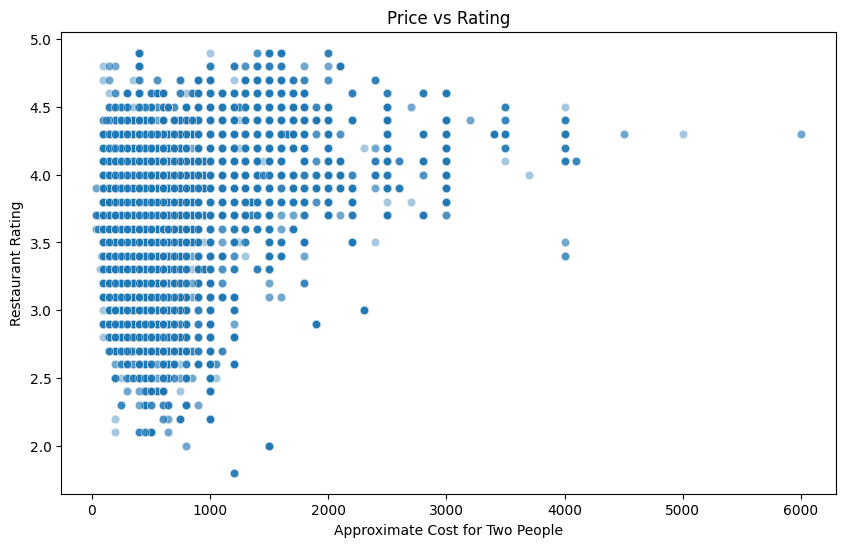

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='approx_cost',
    y='rate',
    alpha=0.4
)

plt.title("Price vs Rating")
plt.xlabel("Approximate Cost for Two People")
plt.ylabel("Restaurant Rating")

plt.show()

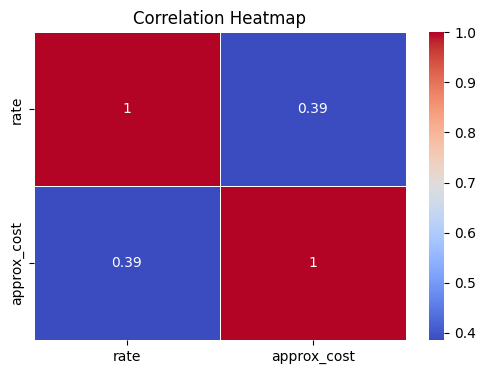

In [20]:
plt.figure(figsize=(6,4))

numeric_df = df[['rate', 'approx_cost']]

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

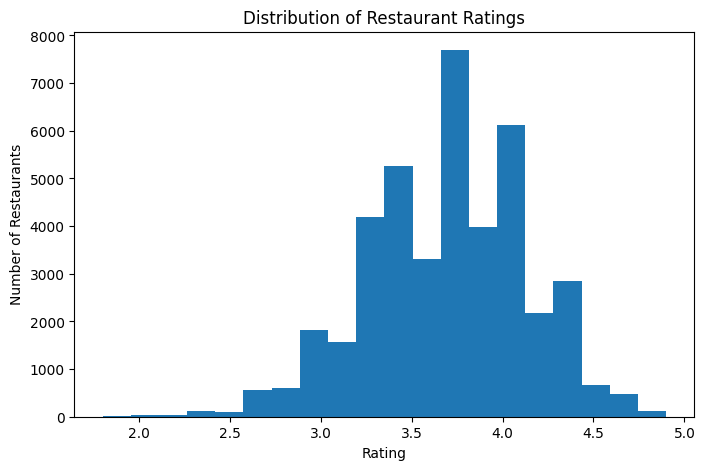

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['rate'], bins=20)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.show()

Observation :

Most restaurants have ratings between 3.5 and 4.2.

Very few restaurants have ratings below 2.5 or above 4.8.

The dataset is dominated by moderately to highly rated restaurants.

In [23]:
df['online_order'].unique()

array(['Yes', 'No', 'Bannerghatta Road', 'Basavanagudi', 'Brigade Road',
       'Brookefield', 'BTM', nan, 'Pubs and bars', 'Church Street', 'HSR',
       'Indiranagar', 'JP Nagar', 'Kammanahalli', 'Delivery',
       'Koramangala 4th Block', " ('Rated 4.0'", 'Koramangala 5th Block',
       'Koramangala 7th Block', 'Lavelle Road', 'Malleshwaram',
       'Marathahalli', 'Dine-out', 'MG Road', 'Drinks & nightlife',
       'Old Airport Road',
       " 'RATED\\n  No this is not the place ..... Most the combos are not available...... And I have never seen anyone over there ...... No crowd at all ...... Always empty...... I tried a tandoor combo.... With jeera rice ..... No words .... It was very very simple ..... No salt ",
       'Residency Road', 'Sarjapur Road', 'Whitefield'], dtype=object)

In [24]:
df['online_order'].value_counts().head(20)

,count
online_order,
Yes,30444
No,21273
MG Road,6
BTM,4
Delivery,3
Koramangala 5th Block,3
Lavelle Road,3
Whitefield,3
Sarjapur Road,2


In [25]:
df = df[df['online_order'].isin(['Yes', 'No'])]

In [26]:
df['online_order'].value_counts()

,count
online_order,
Yes,30444
No,21273


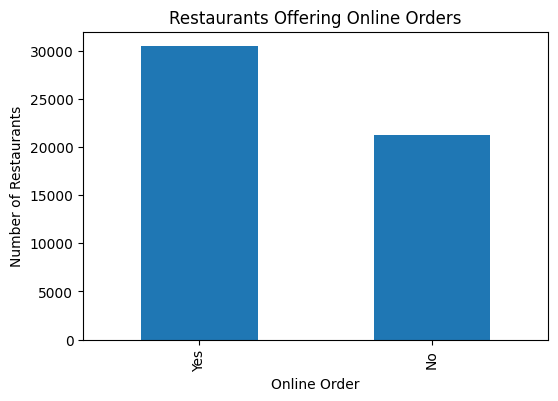

In [27]:
online = df['online_order'].value_counts()

plt.figure(figsize=(6,4))
online.plot(kind='bar')

plt.title("Restaurants Offering Online Orders")
plt.xlabel("Online Order")
plt.ylabel("Number of Restaurants")

plt.show()

In [28]:
df['book_table'].unique()

array(['Yes', 'No'], dtype=object)

In [29]:
df['listed_in(type)'].unique()

array(['Buffet', 'Cafes', nan, 'Delivery', 'Desserts', 'Dine-out',
       'Drinks & nightlife', 'Pubs and bars'], dtype=object)

In [30]:
df['rest_type'].unique()[:20]

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Beverage Shop, Quick Bites', 'Confectionery'], dtype=object)

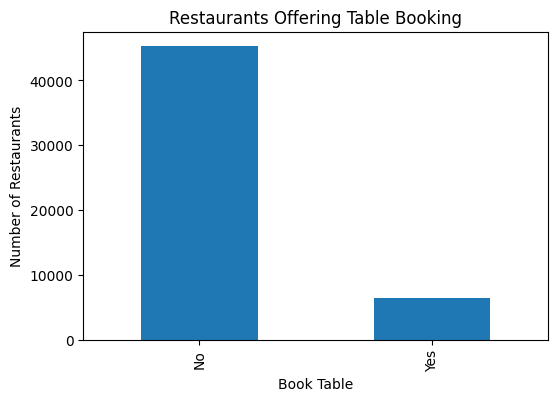

In [31]:
book = df['book_table'].value_counts()

plt.figure(figsize=(6,4))

book.plot(kind='bar')

plt.title("Restaurants Offering Table Booking")
plt.xlabel("Book Table")
plt.ylabel("Number of Restaurants")

plt.show()

Observation:

Most restaurants do not provide table booking.

Only a smaller percentage of restaurants offer advance table reservations.

Table booking is generally more common among premium restaurants.

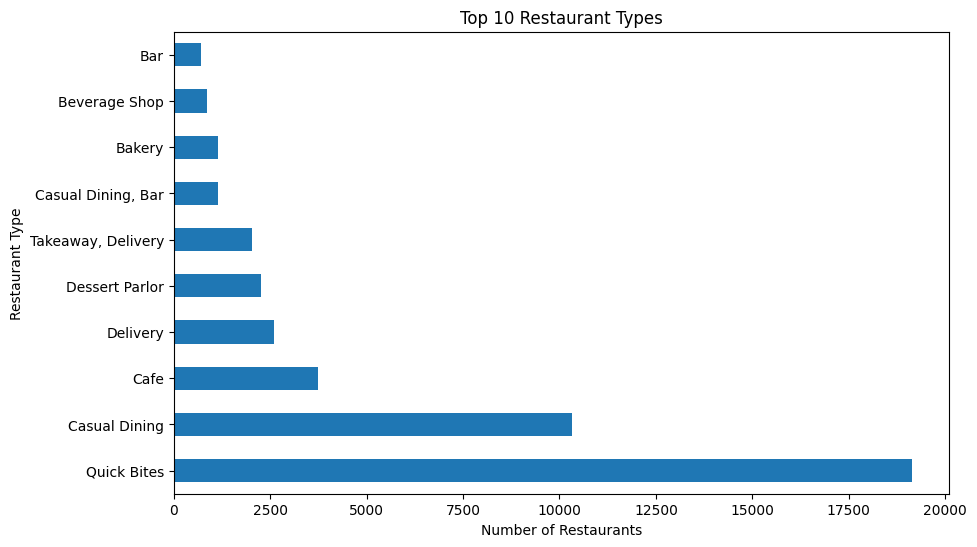

In [32]:
top_rest = df['rest_type'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_rest.plot(kind='barh')

plt.title("Top 10 Restaurant Types")
plt.xlabel("Number of Restaurants")
plt.ylabel("Restaurant Type")

plt.show()

Observation:

Quick Bites and Casual Dining are the most common restaurant types.

Cafés also make up a significant portion of restaurants.
Premium dining formats such as Fine Dining and Pubs are less common.

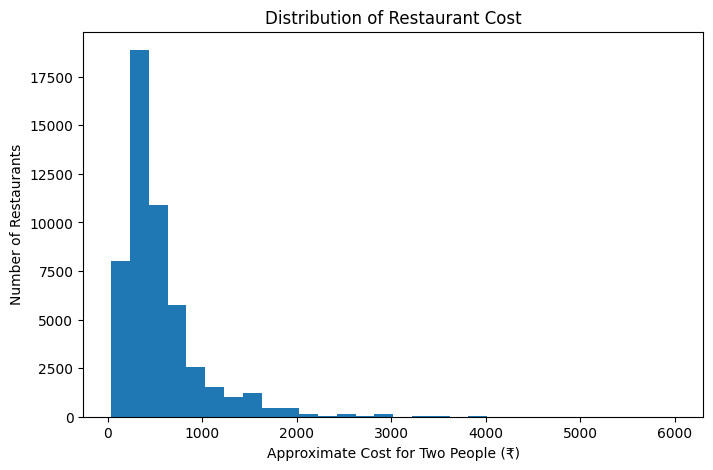

In [33]:
plt.figure(figsize=(8,5))

plt.hist(df['approx_cost'], bins=30)

plt.title("Distribution of Restaurant Cost")
plt.xlabel("Approximate Cost for Two People (₹)")
plt.ylabel("Number of Restaurants")

plt.show()

Observation:

Most restaurants charge between ₹200 and ₹800 for two people.

Very expensive restaurants are relatively few.

Affordable restaurants dominate the dataset.

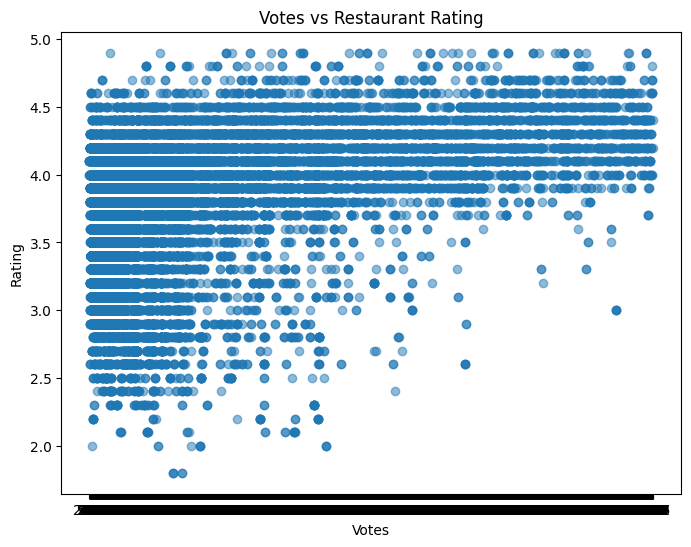

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(df['votes'], df['rate'], alpha=0.5)

plt.title("Votes vs Restaurant Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")

plt.show()

Observation:

Restaurants with more votes generally have higher ratings.

Highly rated restaurants tend to attract more customer reviews.

A few restaurants receive exceptionally high votes, acting as outliers.

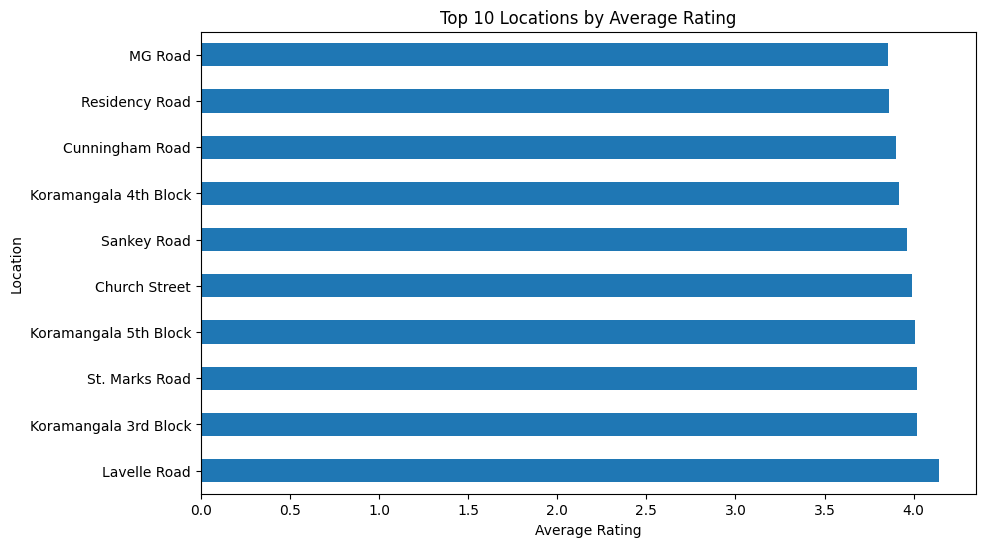

In [35]:
location_rating = df.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

location_rating.plot(kind='barh')

plt.title("Top 10 Locations by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Location")

plt.show()

Observation:

Some locations consistently have higher-rated restaurants.

Premium restaurant areas generally achieve better average ratings.

These locations could be considered food hotspots.

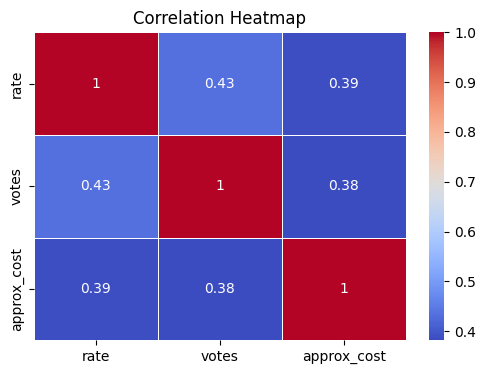

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    df[['rate', 'votes', 'approx_cost']].corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Observation:

Restaurant ratings have a weak positive correlation with the number of votes.

Approximate cost has only a slight relationship with ratings.

There is no strong linear relationship among these variables.

In [38]:
!pip install wordcloud

In [39]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

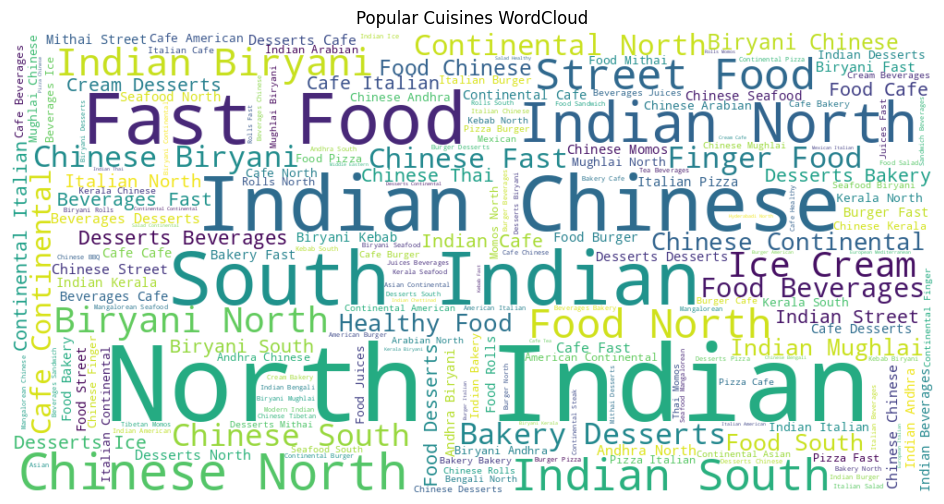

In [40]:
text = " ".join(df['cuisines'].dropna().astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Popular Cuisines WordCloud")
plt.show()

Observation:

North Indian, Chinese, South Indian, Biryani, and Fast Food appear as the most popular cuisines.

Larger words indicate cuisines that are offered by a greater number of restaurants.

The WordCloud provides a quick visual summary of cuisine popularity.

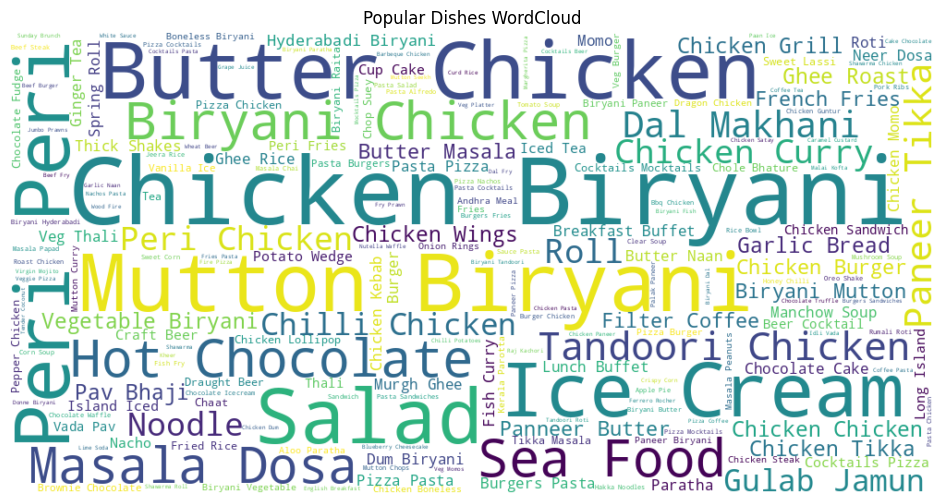

In [41]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['dish_liked'].dropna().astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Popular Dishes WordCloud")
plt.show()

Observation:

Frequently appearing dishes indicate customer favorites.

Popular dishes such as pasta, pizza, biryani, burgers, coffee, waffles, and sandwiches appear prominently.

The WordCloud helps identify trending dishes preferred by customers.

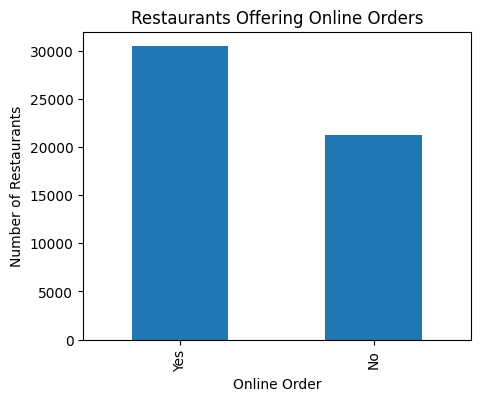

In [42]:
online = df['online_order'].value_counts()

plt.figure(figsize=(5,4))
online.plot(kind='bar')

plt.title("Restaurants Offering Online Orders")
plt.xlabel("Online Order")
plt.ylabel("Number of Restaurants")

plt.show()

Observation:

More restaurants offer online ordering than those that do not.

This indicates that online food delivery is a major business channel for restaurants.

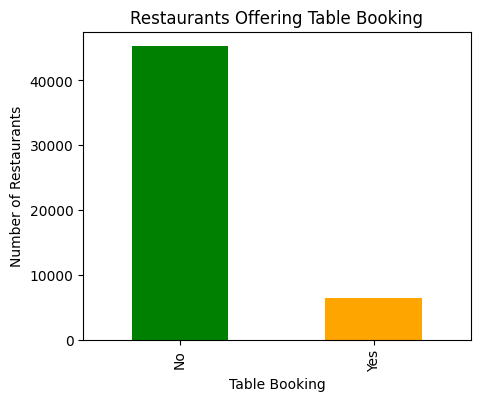

In [43]:
book = df['book_table'].value_counts()

plt.figure(figsize=(5,4))
book.plot(kind='bar', color=['green','orange'])

plt.title("Restaurants Offering Table Booking")
plt.xlabel("Table Booking")
plt.ylabel("Number of Restaurants")

plt.show()

Observation:

Most restaurants do not provide table booking facilities.

Table booking is mainly available in premium or fine-dining restaurants.

Recommendations for Alfido Tech:

1.Partner with highly rated restaurants (4.0+ ratings) to improve customer trust and platform reputation.

2.Focus on food hotspot locations such as BTM, HSR, and Koramangala, where restaurant density is highest.

3.Promote popular cuisines like North Indian, Chinese, South Indian, Biryani, and Fast Food through featured campaigns and personalized recommendations.

4.Encourage online ordering by providing promotional offers and discounts, as most restaurants support online delivery.
Use customer preferences and ratings to build personalized restaurant recommendations, improving user engagement and satisfaction.

Conclusion:

This project analyzed the Zomato restaurant dataset to identify customer preferences, restaurant distribution, cuisine popularity, pricing trends, and rating patterns. After cleaning the dataset and handling missing values, several visualizations were created, including bar charts, scatter plots, a heatmap, and WordClouds. The analysis revealed that restaurant ratings are only weakly related to price, while restaurant location and cuisine type play a significant role in popularity. Food hotspot locations such as BTM and HSR contain the highest number of restaurants, and cuisines like North Indian and Chinese dominate the market. These insights can help platforms like Alfido Tech improve restaurant partnerships, customer recommendations, and marketing strategies.

In [44]:
df.to_csv("zomato_cleaned.csv", index=False)